In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("../../data/raw/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
rf = RandomForestClassifier(
    random_state=42
)

In [27]:
param_grid = {
    "n_estimators": [100, 200, 500]
}

In [28]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [29]:
print(
    grid_search.best_params_
)

{'n_estimators': 200}


In [30]:
best_rf = grid_search.best_estimator_

In [31]:
y_pred = best_rf.predict(
    X_test
)

y_prob = best_rf.predict_proba(
    X_test
)[:,1]

In [32]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

ROC data saved successfully.


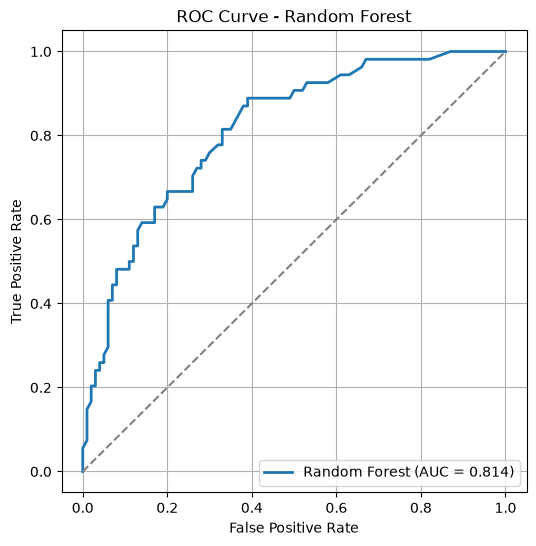

ROC curve saved successfully.


In [33]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import os

# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# ==========================
# Save ROC Data
# ==========================
os.makedirs("../../results/roc", exist_ok=True)

roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr
})

roc_df.to_csv(
    "../../results/roc/roc_random_forest.csv",
    index=False
)

print("ROC data saved successfully.")

# ==========================
# Plot ROC Curve
# ==========================
os.makedirs("../../figures", exist_ok=True)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(
    "../../results/roc/roc_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")

<Figure size 600x600 with 0 Axes>

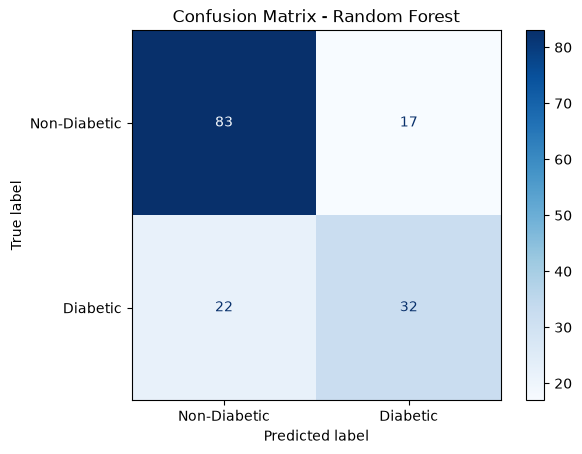

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

plt.figure(figsize=(6,6))

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")

plt.savefig(
    "../../results/matrix/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC ROC  :", auc)

Accuracy : 0.7467532467532467
Precision: 0.6530612244897959
Recall   : 0.5925925925925926
F1 Score : 0.6213592233009708
AUC ROC  : 0.8142592592592592


In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.265887
5,BMI,0.161386
7,Age,0.131131
6,DiabetesPedigreeFunction,0.127057
2,BloodPressure,0.086337
0,Pregnancies,0.083986
4,Insulin,0.073942
3,SkinThickness,0.070273


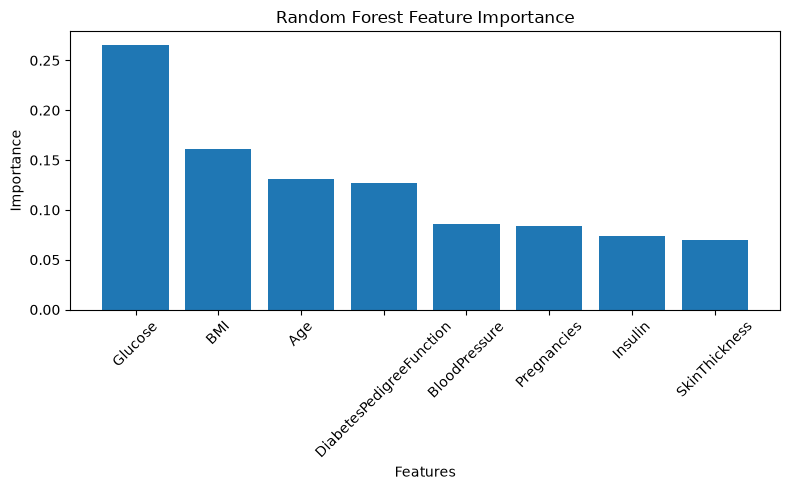

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()

plt.show()

In [38]:
results = pd.read_csv(
    "../../results/results_log.csv"
)

results

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
1,DT,0.694805,0.666667,0.259259,0.373333,0.788056
2,RF,0.746753,0.653061,0.592593,0.621359,0.814259
3,SVM,0.766234,0.686275,0.636364,0.660377,0.737374
4,MLP,0.727273,0.611111,0.611111,0.611111,0.835556
5,DT,0.694805,0.666667,0.259259,0.373333,0.788056


In [39]:
new_row = pd.DataFrame({
    "model": ["RF"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "auc_roc": [auc]
})

In [40]:
results = pd.concat(
    [results, new_row],
    ignore_index=True
)

results

,model,accuracy,precision,recall,f1,auc_roc
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
1,DT,0.694805,0.666667,0.259259,0.373333,0.788056
2,RF,0.746753,0.653061,0.592593,0.621359,0.814259
3,SVM,0.766234,0.686275,0.636364,0.660377,0.737374
4,MLP,0.727273,0.611111,0.611111,0.611111,0.835556
5,DT,0.694805,0.666667,0.259259,0.373333,0.788056
6,RF,0.746753,0.653061,0.592593,0.621359,0.814259


In [41]:
results.to_csv(
    "../../results/results_log.csv",
    index=False
)

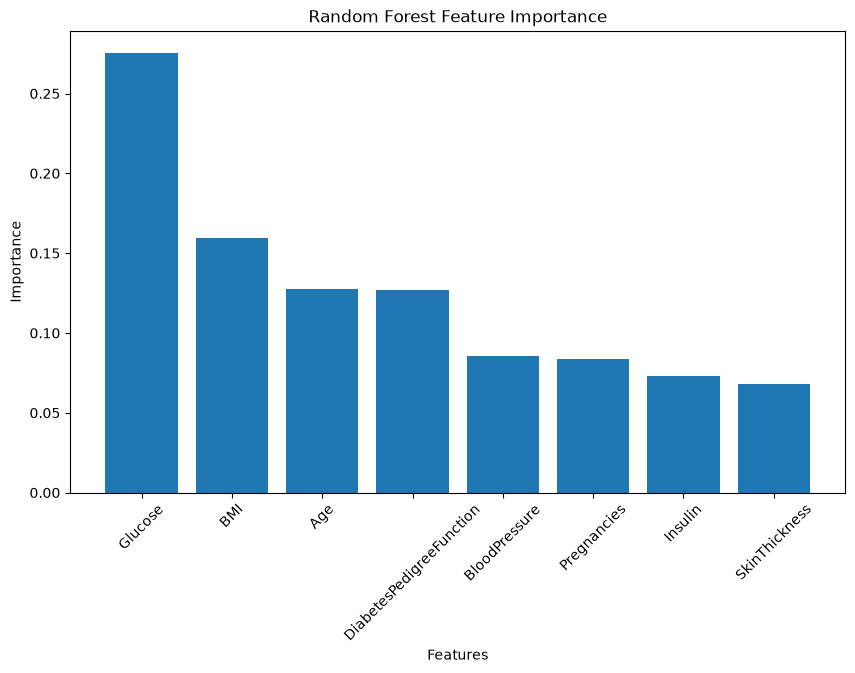

Graph saved successfully!


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("../../data/raw/diabetes.csv")

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Get feature importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Create results folder
os.makedirs("../results", exist_ok=True)

# Plot
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

# Save graph
plt.savefig(
    "../results/feature_importance_rf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully!")